# Cox-Ingersoll-Ross - one -factor short rate model

Used to model, for example, interest rate or credit spreads

Short-rate dynamics:
$$
dr_t = a(b - r_t)dt + \sigma*sqrt(r_t)dW_t
$$

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.special import iv  # modified Bessel function
from scipy.optimize import minimize

In [5]:
ticker = "^IRX"  # 13-week Treasury bill
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")

rates = data["Close"].dropna() / 100.0  # convert % → decimal
rates = rates.values

dt = 1/252  # daily data (trading days)

C:\Users\nadia\AppData\Local\Temp\ipykernel_30984\501337773.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [6]:
def cir_neg_log_likelihood(params, r, dt):
    kappa, theta, sigma = params
    
    # enforce positivity
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    
    n = len(r)
    ll = 0.0
    
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)))
    q = 2 * kappa * theta / sigma**2 - 1
    
    for t in range(n - 1):
        rt = r[t]
        rt1 = r[t+1]
        
        u = c * rt * np.exp(-kappa * dt)
        v = c * rt1
        
        # avoid numerical issues
        if u <= 0 or v <= 0:
            return 1e10
        
        # log density
        log_pdf = (
            np.log(c)
            - (u + v)
            + (q / 2) * (np.log(v) - np.log(u))
            + np.log(iv(q, 2 * np.sqrt(u * v)))
        )
        
        ll += log_pdf
    
    return -ll  # negative log-likelihood

In [7]:
# initial guesses
init_params = np.array([1.0, 0.05, 0.1])

bounds = [
    (1e-5, 10),    # kappa
    (1e-5, 0.2),   # theta
    (1e-5, 1.0)    # sigma
]

result = minimize(
    cir_neg_log_likelihood,
    init_params,
    args=(rates, dt),
    method="L-BFGS-B",
    bounds=bounds
)

kappa_hat, theta_hat, sigma_hat = result.x

print("Estimated parameters:")
print(f"kappa = {kappa_hat:.4f}")
print(f"theta = {theta_hat:.4f}")
print(f"sigma = {sigma_hat:.4f}")

Estimated parameters:
kappa = 1.0000
theta = 0.0500
sigma = 0.1000


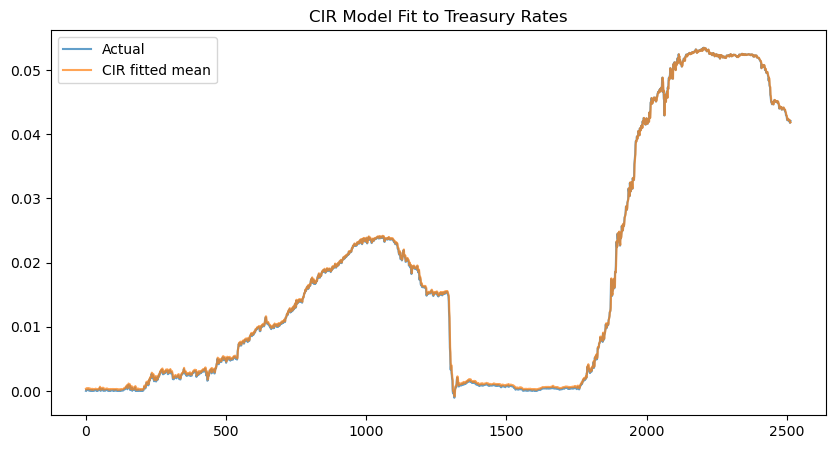

In [8]:
# conditional mean of CIR
def cir_mean(rt, kappa, theta, dt):
    return theta + (rt - theta) * np.exp(-kappa * dt)

predicted = np.array([
    cir_mean(rates[i], kappa_hat, theta_hat, dt)
    for i in range(len(rates)-1)
])

plt.figure(figsize=(10,5))
plt.plot(rates[1:], label="Actual", alpha=0.7)
plt.plot(predicted, label="CIR fitted mean", alpha=0.7)
plt.legend()
plt.title("CIR Model Fit to Treasury Rates")
plt.show()